##  Alignment - GW4 experiments

#### Goal:

* Initial experiments of aligning distributions using Gromov-Wasserstein.
* Align in $\mathbb{R}^3$ for understanding purposes.
* Visually and intuitively explain constraints regarding alignment and matching.

In [ ]:
import numpy as np
import scipy
import matplotlib.pyplot as plt

from scipy.optimize import minimize
from scipy.stats import vonmises_fisher
from scipy.spatial.distance import pdist, squareform
from scipy.spatial.transform import Rotation as Rot

from colors import color_segment
from utils_GW import *
from plot_GW import *

In [29]:
blue_pink = color_segment()

In [10]:
# --- deformation and mesh utilities ---

def get_rotation_matrix(theta):
    """
    Generates a 3x3 rotation matrix using the matrix exponential of a skew-symmetric matrix.
    Inputs: theta (array of 3 angles)
    Outputs: R (3x3 rotation matrix)
    """
    tx, ty, tz = theta
    # Skew-symmetric matrix representation of the rotation vector
    A = np.array([[0, -tz, ty],
                  [tz, 0, -tx],
                  [-ty, tx, 0]])
    return scipy.linalg.expm(A)

def construct_sphere_mesh(n_resolution):
    """
    Objective: Create vertices and faces for a standard unit sphere mesh (S2).
    Logic: Uses spherical coordinates discretized by n_resolution.
    Inputs: n_resolution (int)
    Outputs: vertices (N x 3), faces (M x 3)
    """
    # Create a grid of phi (0 to pi) and theta (0 to 2*pi)
    phi = np.linspace(0, np.pi, n_resolution)
    theta = np.linspace(0, 2 * np.pi, n_resolution)
    phi_grid, theta_grid = np.meshgrid(phi, theta)

    # Convert spherical coordinates to Cartesian coordinates for the unit sphere
    x = np.sin(phi_grid) * np.cos(theta_grid)
    y = np.sin(phi_grid) * np.sin(theta_grid)
    z = np.cos(phi_grid)

    # Flatten grids to create N x 3 vertex array
    vertices = np.stack([x.flatten(), y.flatten(), z.flatten()], axis=1)

    # Generate face indices for the grid structure
    faces = []
    for i in range(n_resolution - 1):
        for j in range(n_resolution - 1):
            # Define indices for the corners of each quad on the grid
            p1 = i * n_resolution + j
            p2 = p1 + 1
            p3 = (i + 1) * n_resolution + j
            p4 = p3 + 1
            # Split quad into two triangles
            faces.append([p1, p2, p3])
            faces.append([p2, p4, p3])
            
    return vertices, np.array(faces)

def create_deformation_params(seed, n_terms=4):
    rng = np.random.RandomState(seed)

    params = []
    for _ in range(n_terms):
        a = rng.uniform(0.2, 0.6)
        w = rng.uniform(1.0, 4.0, size=3)
        phase = rng.uniform(-np.pi, np.pi)

        params.append((a, w, phase))

    return params

def smooth_field(points, params):
    x = points[:, 0]
    y = points[:, 1]
    z = points[:, 2]

    base = np.zeros(len(points))

    for a, w, phase in params:
        base += a * np.sin(w[0]*x + w[1]*y + w[2]*z + phase)

    return base

def deform_sphere(points_on_sphere, alpha, params):
    """
    Objective: Implement the push-forward map f: S2 -> Manifold
    Logic: Implements the push-forward operator by moving point positions
           Perturbs the radial component so that |z| != 1 using non-symmetric noise.
    Inputs: points_on_sphere (N x 3), noise_params (dict with 'amplitude' and 'freq')
    Outputs: deformed_points (N x 3)
    """
    base = smooth_field(points_on_sphere, params)

    radial_scale = 1.0 + alpha * 0.25 * base

    return points_on_sphere * radial_scale[:, None]


def deform_mesh(mesh, alpha, params):
    vertices, faces = mesh
    return deform_sphere(vertices, alpha, params), faces



In [6]:
# --- compute geodesics ---

def compute_geodesics(points, is_sphere=True):
    """
    Computes the pairwise intra-distance matrix D.
    Inputs: points (N x 3), is_sphere (bool toggle)
    Outputs: D (N x N distance matrix)
    """
    if is_sphere:
        # Vectorized spherical distance: arccos(Xi * Xj)
        # Using np.clip to prevent numerical errors outside [-1, 1]
        inner_prod = np.inner(points, points)
        return np.arccos(np.clip(inner_prod, -1.0, 1.0))
    else:
        # Euclidean approximation for deformed objects
        # Using scipy's efficient pdist/squareform for ||xi - xj||
        return squareform(pdist(points, 'euclidean'))
    

# --- distributions ---

def sample_vmf_on_sphere(mu, kappa, n_samples):
    """
    Objective: Properly sample from a Von Mises-Fisher distribution on the unit sphere.
    Logic: Ensures the mean direction is normalized and uses scipy to sample 
           directly on the S2 manifold where ||z|| = 1.
    Inputs: mu (mean direction), kappa (concentration), n_samples (int)
    Outputs: points (n_samples x 3) where ||z|| = 1
    """
    # Ensure the mean direction is a unit vector
    mu_normalized = mu / np.linalg.norm(mu)
    
    # Sample directly from the VMF distribution on the sphere
    points = vonmises_fisher.rvs(mu_normalized, kappa, size=n_samples)
    
    return points

def symmetric_samples_vmf(mu, layer_radii, points_per_layer):
    """
    Construct symmetric vMF-like samples on S^2 around mean direction mu.

    Parameters
    ----------
    mu : (3,) array
        Mean direction (will be normalized)
    layer_radii : list or array
        Radii (angular offsets) for each ring
    points_per_layer : int
        Number of points per ring

    Returns
    -------
    data : (N,3) array
        Symmetric samples on the sphere
    """
    mu = mu.astype(float)
    mu = mu / np.linalg.norm(mu)

    # Build orthonormal basis (v1, v2) ⟂ mu
    if np.allclose(mu, np.array([1., 0., 0.])):
        v1 = np.array([0., 1., 0.])
    else:
        v1 = np.cross(mu, np.array([1., 0., 0.]))
        if np.linalg.norm(v1) < 1e-8:
            v1 = np.cross(mu, np.array([0., 1., 0.]))

    v1 = v1 / np.linalg.norm(v1)
    v2 = np.cross(mu, v1)

    data_points = []

    for r in layer_radii:
        angles = np.linspace(0, 2*np.pi, points_per_layer, endpoint=False)

        layer = (
            mu[None, :]
            + r * np.cos(angles)[:, None] * v1[None, :]
            + r * np.sin(angles)[:, None] * v2[None, :]
        )

        # Project to sphere
        layer /= np.linalg.norm(layer, axis=1, keepdims=True)
        data_points.append(layer)

    return np.vstack(data_points)


In [7]:
# --- compute loss ---

def gromov_wasserstein_loss(D1, D2, P):
    """
    Objective: Calculate the GW objective discrepancy between two intra-distance matrices.
    Logic: Uses an efficient matrix expansion of the quadratic objective:
           Loss = sum_{i,j,i',j'} |D1_ii' - D2_jj'|^2 * P_ij * P_i'j'
           Expanded: C1 + C2 - 2 * (D1 @ P @ D2).
    Inputs: D1 (N x N), D2 (M x M), P (N x M coupling matrix)
    Outputs: gw_loss (float)
    """
    # Extract marginals from the coupling matrix P
    # a: mass distribution on the source manifold
    # b: mass distribution on the target manifold
    a = np.sum(P, axis=1)
    b = np.sum(P, axis=0)

    # Compute constant terms relative to the distance matrices and marginals
    # These represent the 'self-similarities' of each space
    C1 = np.dot(np.dot(D1**2, a[:, np.newaxis]), np.ones((1, len(b))))
    C2 = np.dot(np.ones((len(a), 1)), np.dot(b[np.newaxis, :], (D2**2).T))

    # Compute the cross-term (linearized gradient term)
    # This captures how the pairwise distances align across the manifolds
    cross_term = 2 * np.dot(D1, np.dot(P, D2))

    # The full cost matrix for the current coupling P
    cost_matrix = C1 + C2 - cross_term

    # Final discrepancy is the sum of cost weighted by the transport plan
    return np.sum(cost_matrix * P)


def rotation_alignment_loss(R, points1, points2, P):
    """
    Objective: Compute the L2 alignment loss for rotated points under a given coupling.
    Logic: Transports mass from 'points1' to the rotated 'points2' according to P.
    Inputs: R (3x3), points1 (N x 3), points2 (M x 3), P (N x M coupling)
    Outputs: alignment_loss (float)
    """
    # Apply the candidate rotation matrix R to the target point cloud
    rotated_points2 = (R @ points2.T).T

    # Compute pairwise squared Euclidean distances between source and rotated target
    diff = points1[:, np.newaxis, :] - rotated_points2[np.newaxis, :, :]
    squared_euclidean_cost = np.sum(diff**2, axis=2)

    # The loss is the total work required to move source mass to aligned target mass
    return np.sum(squared_euclidean_cost * P)



In [8]:
# --- optimizer ---

def solve_sinkhorn_coupling(cost_matrix, epsilon, a, b, pairs=None):
    """
    Objective: Solve for the optimal coupling matrix P using Sinkhorn iterations.
    Logic: Implements the entropic regularization of OT. In paired experiments, 
           modifies the cost matrix to 'lock' anchor mass between specific indices.
    Inputs: cost_matrix (N x M), epsilon (reg parameter), a/b (marginals), pairs (list of tuples, optional)
    Outputs: P (optimal coupling matrix)
    """
    # Work on a copy of the cost matrix to ensure integrity
    C = np.copy(cost_matrix)
    
    # If pairs are provided (Experiment 2), bias the cost matrix 
    # This acts as a hard constraint for the anchor point
    if pairs is not None:
        large_penalty = 1e2
        for i, j in pairs:
            # Penalize all other matches for these rows and columns
            C[i, :] = large_penalty
            C[:, j] = large_penalty
            # Set zero cost for the ground-truth correspondence
            C[i, j] = 0.0
            
    # Compute the Gibbs kernel:
    K = np.exp(-C / epsilon)
    
    # Initialize scaling vectors
    n, m = C.shape
    u = np.ones(n) / n
    
    # Perform Sinkhorn iterations to satisfy marginal constraints
    # These iterations consist of simple matrix-vector products
    for _ in range(100):
        # Update v (target scaling)
        v = b / (K.T @ u + 1e-16)
        # Update u (source scaling)
        u = a / (K @ v + 1e-16)
        
    # Reconstruct the optimal coupling matrix P = diag(u) K diag(v)
    P = u[:, np.newaxis] * K * v[np.newaxis, :]
    return P


def optimize_rotation(initial_params, points1, points2, coupling_P, pairs=None):
    """
    Objective: Wrapper for scipy.optimize.minimize to find the best rotation R.
    Logic: Minimizes rotation_alignment_loss. If pairs exist, it initializes theta 
           to align anchors, helping the optimizer avoid local minima in symmetric spaces.
    Inputs: initial_params (array), points1 (N x 3), points2 (M x 3), coupling_P (N x M), pairs (list, optional)
    Outputs: optimal_theta (array of 3 angles)
    """
    start_theta = np.copy(initial_params)
    
    # Symmetry Breaking: If a pair is provided, use it to improve the initial guess
    # For S2, fixing one point leaves only rotation around that axis as a degree of freedom
    if pairs is not None and len(pairs) > 0:
        # Use the first pair as a geometric anchor
        idx1, idx2 = pairs
        v_src = points1[idx1]
        v_tgt = points2[idx2]
        
        # Calculate a rotation vector that aligns the target anchor with the source
        axis = np.cross(v_tgt, v_src)
        norm = np.linalg.norm(axis)
        if norm > 1e-6:
            axis /= norm
            angle = np.arccos(np.clip(np.dot(v_src, v_tgt), -1.0, 1.0))
            start_theta = axis * angle

    # Define the objective wrapper for the optimizer
    def objective(theta):
        # get_rotation_matrix uses matrix exponential to ensure a valid SO(3) matrix
        R = get_rotation_matrix(theta)
        return rotation_alignment_loss(R, points1, points2, coupling_P)

    # Use L-BFGS-B to find the optimal rotation parameters (theta_x, theta_y, theta_z)
    res = minimize(objective, start_theta, method='L-BFGS-B')
    
    return res.x

In [9]:
# --- evaluate alignment  (not used) ---

# Does not use right, idea might be good enough
def evaluate_alignment(P, pairs):
    """
    Objective: Quantify the accuracy of the transport/alignment.
    Logic: For each source point, it identifies the target point receiving 
           the maximum transport mass (argmax of P) and checks if it matches 
            the ground truth correspondence.
    Inputs: P (coupling matrix N x M), pairs (list of tuples [(src_idx, tgt_idx), ...])
    Outputs: precision (float between 0 and 1)
    """
    if not pairs:
        return 0.0
    
    correct_matches = 0
    # The coupling matrix P represents the joint probability of correspondences.
    for src_idx, tgt_idx in pairs:
        # Determine the target index with the highest probability match for src_idx
        predicted_idx = np.argmax(P[src_idx, :])
        
        if predicted_idx == tgt_idx:
            correct_matches += 1
            
    # Precision measures the ratio of correctly recovered correspondences
    precision = correct_matches / len(pairs)
    return precision


In [10]:
# --- plotting functions ---

# (KDE only for plotting)
def spherical_kde_density(points, kappa=40, res=200):
    """
    Kernel density estimate on S^2 using vMF kernels centered at data points.
    """
    theta = np.linspace(0, np.pi, res)
    phi = np.linspace(0, 2*np.pi, res)
    Theta, Phi = np.meshgrid(theta, phi)

    X = np.stack([
        np.cos(Phi) * np.sin(Theta),
        np.sin(Phi) * np.sin(Theta),
        np.cos(Theta)
    ], axis=-1)   # (res,res,3)

    pts = points / np.linalg.norm(points, axis=1, keepdims=True)

    dot = np.einsum("...i,ni->...n", X, pts)

    density = np.exp(kappa * dot).mean(axis=-1)

    density /= density.max()

    return Theta, Phi, density

def add_density_contours_s2(ax3d, points, levels=(0.4,0.6,0.8), res=200,
                           kappa=40, color="gray", alpha=0.35, linewidth=2):

    Theta, Phi, density = spherical_kde_density(points, kappa=kappa, res=res)

    fig2, ax2d = plt.subplots()
    CS = ax2d.contour(Theta, Phi, density, levels=list(levels))
    plt.close(fig2)

    for lvl_segs in CS.allsegs:
        for seg in lvl_segs:
            theta = seg[:,0]
            phi = seg[:,1]

            x = np.cos(phi)*np.sin(theta)
            y = np.sin(phi)*np.sin(theta)
            z = np.cos(theta)

            ax3d.plot(x, y, z, color=color, alpha=alpha, linewidth=linewidth)

def euclidean_kde_density(points, query_points, sigma=0.15):
    diff = query_points[:, None, :] - points[None, :, :]
    dist2 = np.sum(diff**2, axis=-1)
    density = np.exp(-dist2 / (2 * sigma**2)).mean(axis=1)
    return density


def add_density_contours_mesh(ax3d, mesh, points, levels=(0.4,0.6,0.8), sigma=0.15):
    vertices, faces = mesh

    density = euclidean_kde_density(points, vertices, sigma=sigma)
    density /= density.max()

    for lvl in levels:
        mask = np.abs(density - lvl) < 0.02

        ax3d.scatter(
            vertices[mask, 0],
            vertices[mask, 1],
            vertices[mask, 2],
            s=5,
            alpha=0.6
        )

    
def plot_object_points(mesh, points, point_colors, ax, show_contours=False, is_sphere=True):
    """
    Objective: Primary visualization tool for metric measure space alignment.
    Logic: Renders the object surface and overlays data-driven 
           density contours to visualize the probability measure signature.
    """
    vertices, faces = mesh

    ax.plot_trisurf(
        vertices[:,0], vertices[:,1], vertices[:,2],
        triangles=faces, cmap=blue_pink, alpha=0.1, edgecolor='none'
    )

    ax.scatter(
        points[:,0], points[:,1], points[:,2],
        c=point_colors, s=25, alpha=0.8,
        edgecolor='white', linewidth=0.3
    )

    if show_contours:
        if is_sphere:
            add_density_contours_s2(ax, points, color=point_colors)
        else:
            add_density_contours_mesh(ax, mesh, points)

    ax.set_box_aspect((1,1,1))
    ax.axis("off")


def plot_alignment_dashboard(src_data, tgt_data, theta_est, src_mesh, tgt_mesh, 
                             x_pair_src = None, x_pair_tgt = None, show_contours=False, is_sphere=True, view_angle=(-30, 0),
                             probe_points=None, mean_dir=None):
    """
    Objective: 3-panel dashboard to verify GW alignment.
    """

    R_final = get_rotation_matrix(theta_est)
    aligned_tgt = (R_final @ tgt_data.T).T

    fig = plt.figure(figsize=(18,6))

    ax1 = fig.add_subplot(131, projection='3d')
    plot_object_points(src_mesh, src_data, 'blue', ax1, show_contours, is_sphere)
    if x_pair_src is not None:
        ax1.scatter(x_pair_src[0], x_pair_src[1], x_pair_src[2], color='green', s=100)
    ax1.set_title("Source")
    ax1.view_init(*view_angle)

    ax2 = fig.add_subplot(132, projection='3d')
    plot_object_points(tgt_mesh, tgt_data, 'red', ax2, show_contours, is_sphere)
    if x_pair_tgt is not None:
        ax2.scatter(x_pair_tgt[0], x_pair_tgt[1], x_pair_tgt[2], color='purple', s=100)
    ax2.set_title("Target")
    ax2.view_init(*view_angle)

    ax3 = fig.add_subplot(133, projection='3d')
    plot_object_points(src_mesh, src_data, 'blue', ax3, show_contours, is_sphere)

    if x_pair_src is not None:
        ax3.scatter(x_pair_src[0], x_pair_src[1], x_pair_src[2], color='green', s=200)
    if x_pair_tgt is not None:
        x_pair_tgt_aligned = R_final @ x_pair_tgt
        ax3.scatter(
            x_pair_tgt_aligned[0],
            x_pair_tgt_aligned[1],
            x_pair_tgt_aligned[2],
            color='purple',
            s=100
        )
    ax3.view_init(*view_angle)

    ax3.scatter(
        aligned_tgt[:,0], aligned_tgt[:,1], aligned_tgt[:,2],
        color='red', s=20, alpha=0.8
    )

    if show_contours:
        add_density_contours_s2(ax3, aligned_tgt, color="red")

    ax3.set_title("Alignment Result")

    plt.tight_layout()
    plt.show()

#### 1. Symmetric vMFs (no pairs)

Hypothesis: Aligning two VMFs on each their respective S2s will not be a unique rotation.

Reason: Symmetric data points on a symmetric geometric object measured using GW will have no way of differentiating between how the distribution is rotated around the mean of the distribution. Aligning two isometric vMFs can have inifitinetely many rotations where the GW distance is the same, i.e. different choices of theta will result in the same minimal GW distance and therefore the alignment will not be unique, but with regard to the GW objective loss the solutions are equally good.

In [12]:
# single symmetric vmf (no pairs)
# -------------------------
np.random.seed(42)
n_layers = 3
points_per_layer = 4
layer_radii = [0.1, 0.2, 0.3]  # angular deviations
epsilon = 0.01
n_res = 50
threshold = 1e-8


# Mean direction
mu = np.array([1., 0., 0.]) 
mu = mu / np.linalg.norm(mu)

# Create orthonormal basis perpendicular to mu
if mu[0] == 1.0:
    v1 = np.array([0., 1., 0.])
else:
    v1 = np.cross(mu, np.array([1.,0.,0.]))
v1 /= np.linalg.norm(v1)
v2 = np.cross(mu, v1)

# Construct symmetric vMF distribution
data_points = []
for r in layer_radii:
    theta = np.linspace(0, 2*np.pi, points_per_layer, endpoint=False)
    layer_points = [mu + r*np.cos(t)*v1 + r*np.sin(t)*v2 for t in theta]
    layer_points = np.array(layer_points)
    layer_points /= np.linalg.norm(layer_points, axis=1)[:, None]  # project to sphere
    data_points.append(layer_points)

data_src = np.vstack(data_points)
n_samples = data_src.shape[0]


theta_true = np.array([np.pi/2, np.pi/3, np.pi/5])
R_true = get_rotation_matrix(theta_true)
data_tgt = (R_true @ data_src.T).T

src_mesh = construct_sphere_mesh(n_res)
tgt_mesh = construct_sphere_mesh(n_res)

D_src = compute_geodesics(data_src, is_sphere=True)
D_tgt = compute_geodesics(data_tgt, is_sphere=True)

a = np.ones(n_samples) / n_samples
b = np.ones(n_samples) / n_samples


# GW-Sinkhorn initialization
P_learned = a[:, np.newaxis] @ b[np.newaxis, :]
gw_dist_old = float('inf')
converged = False

while not converged:
    # Linearization step
    cost_gradient = - np.dot(np.dot(D_src, P_learned), D_tgt)
    P_learned = solve_sinkhorn_coupling(cost_gradient, epsilon, a, b)
    gw_dist_new = gromov_wasserstein_loss(D_src, D_tgt, P_learned)
    if abs(gw_dist_new - gw_dist_old) < threshold:
        converged = True
    gw_dist_old = gw_dist_new


theta_est = optimize_rotation(np.zeros(3), data_src, data_tgt, P_learned)

final_gw = gromov_wasserstein_loss(D_src, D_tgt, P_learned)
print("--- Single Symmetric vMF Experiment ---")
print(f"Learned Theta (est): {np.round(theta_est, 4)}")
print(f"Ground Truth Theta:  {np.round(theta_true, 4)}")
print(f"Final GW Distance: {final_gw:.6f}")
print("--------------------------------------")

--- Single Symmetric vMF Experiment ---
Learned Theta (est): [-0.     -0.1594 -1.0696]
Ground Truth Theta:  [1.5708 1.0472 0.6283]
Final GW Distance: 0.037392
--------------------------------------


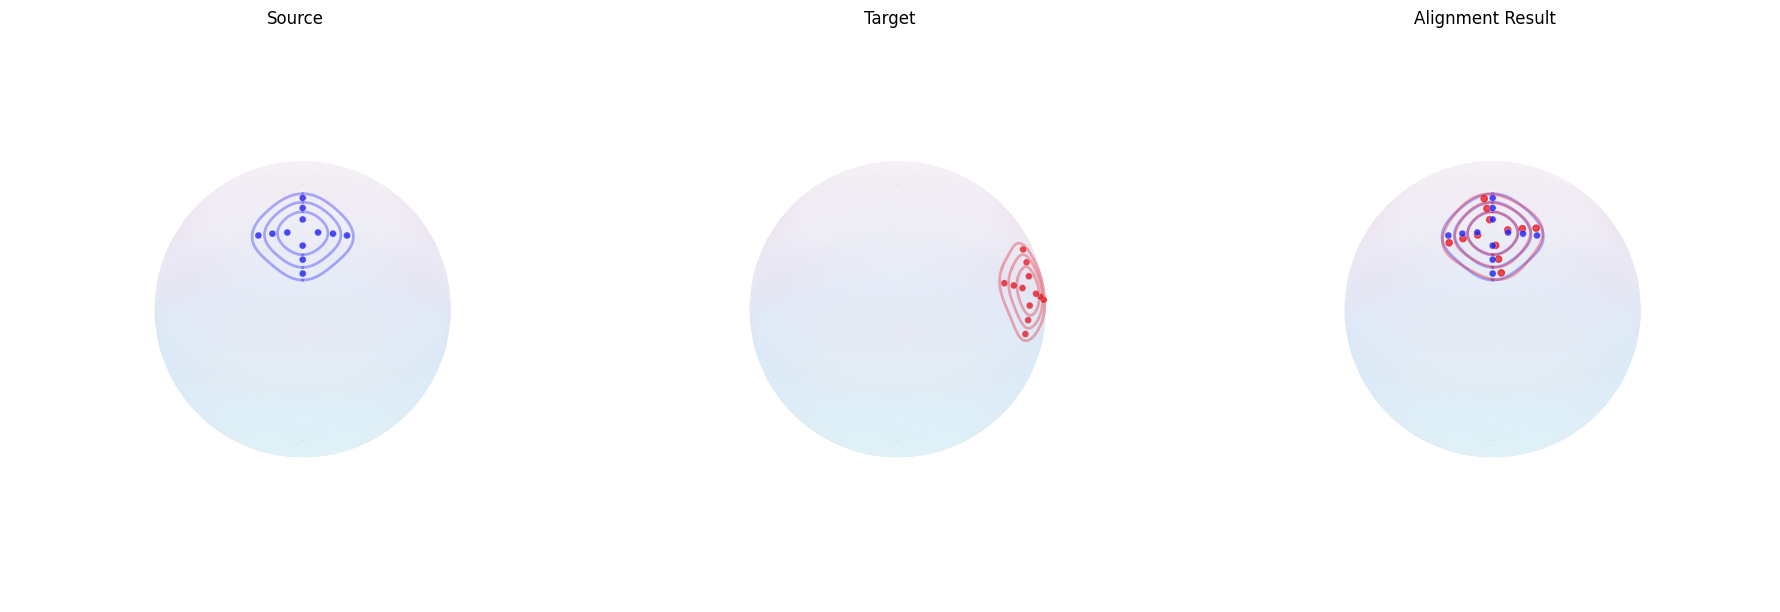

In [14]:
plot_alignment_dashboard(
    data_src, data_tgt, theta_est, 
    src_mesh, tgt_mesh, 
    show_contours=True,
    view_angle=(-30, 0)
)

Here the *distribution mean alignment* is obvious, although as well as the rotational symmetry around the mean value, the found alignment is not an exact match of the sampled points. As the samples are chosen so that the distribution is symmetric it is invariant under rotations around mu.

In [13]:
# symmetric vmf with multiple random theta initializations
# -------------------------

np.random.seed(42)
n_layers = 3
points_per_layer = 4
layer_radii = [0.1, 0.2, 0.3]  # angular deviations
epsilon = 0.01
n_res = 50
threshold = 1e-8
n_theta_inits = 15

# Mean direction
mu = np.array([1., 0., 0.]) 
mu = mu / np.linalg.norm(mu)

# Create orthonormal basis perpendicular to mu
data_src = symmetric_samples_vmf(mu, layer_radii, points_per_layer)
n_samples = data_src.shape[0]


# Hidden rotation
theta_true = np.array([np.pi/2, np.pi/3, np.pi/5]) # some arb rotation
R_true = get_rotation_matrix(theta_true)
data_tgt = (R_true @ data_src.T).T

# Sphere meshes
src_mesh = construct_sphere_mesh(n_res)
tgt_mesh = construct_sphere_mesh(n_res)

# Compute intrinsic geometries
D_src = compute_geodesics(data_src, is_sphere=True)
D_tgt = compute_geodesics(data_tgt, is_sphere=True)

a = np.ones(n_samples) / n_samples
b = np.ones(n_samples) / n_samples

# GW-Sinkhorn initialization
P_learned = a[:, np.newaxis] @ b[np.newaxis, :]
gw_dist_old = float('inf')
converged = False

while not converged:
    cost_gradient = - np.dot(np.dot(D_src, P_learned), D_tgt)
    P_learned = solve_sinkhorn_coupling(cost_gradient, epsilon, a, b)
    gw_dist_new = gromov_wasserstein_loss(D_src, D_tgt, P_learned)
    if abs(gw_dist_new - gw_dist_old) < threshold:
        converged = True
    gw_dist_old = gw_dist_new

# Optimize rotation from multiple random initializations
theta_estimates = []
gw_estimates = []
for _ in range(n_theta_inits):
    init_theta = np.random.randn(3)  
    theta_est = optimize_rotation(init_theta, data_src, data_tgt, P_learned)
    theta_estimates.append(theta_est)
    gw_estimates.append(gromov_wasserstein_loss(D_src, D_tgt, P_learned))


mean_gw = np.mean(gw_estimates)
print("--- Single Symmetric vMF Experiment (Multiple Random Initialized Thetas) ---")
for i, theta_est in enumerate(theta_estimates):
    print(f"Init {i}: Learned Theta (est): {np.round(theta_est,4)}")
print(f"Ground Truth Theta:  {np.round(theta_true, 4)}")
print(f"Mean GW Distance: {mean_gw:.6f}")
print("-------------------------------------------------------------")


--- Single Symmetric vMF Experiment (Multiple Random Initialized Thetas) ---
Init 0: Learned Theta (est): [ 0.4094  0.0866 -1.0866]
Init 1: Learned Theta (est): [ 1.2768  0.6279 -0.9878]
Init 2: Learned Theta (est): [ 1.6706  0.8842 -0.8721]
Init 3: Learned Theta (est): [ 0.2642 -0.0013 -1.085 ]
Init 4: Learned Theta (est): [-0.481  -0.4411 -1.0005]
Init 5: Learned Theta (est): [-1.2027 -0.848  -0.7912]
Init 6: Learned Theta (est): [-2.759  -1.6274  0.3182]
Init 7: Learned Theta (est): [-0.0422 -0.1844 -1.0657]
Init 8: Learned Theta (est): [-0.2798 -0.3242 -1.0359]
Init 9: Learned Theta (est): [ 0.04   -0.1356 -1.073 ]
Init 10: Learned Theta (est): [ 0.7755  0.3115 -1.0684]
Init 11: Learned Theta (est): [-0.3768 -0.3807 -1.02  ]
Init 12: Learned Theta (est): [-0.6055 -0.5127 -0.9737]
Init 13: Learned Theta (est): [ 0.6628  0.2418 -1.0775]
Init 14: Learned Theta (est): [-0.1133 -0.2265 -1.0581]
Ground Truth Theta:  [1.5708 1.0472 0.6283]
Mean GW Distance: 0.037392
----------------------

All the thetas are different yet the GW distance is the same over all runs.

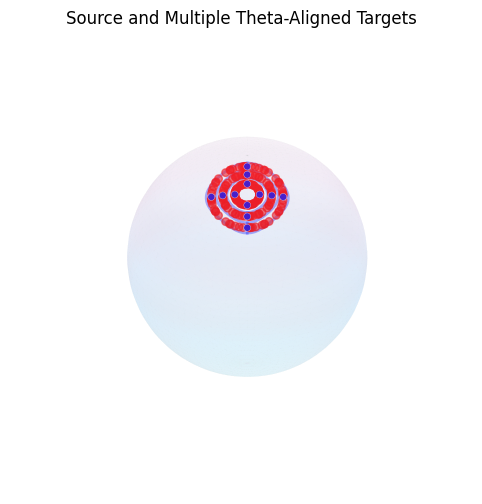

In [16]:
# Plot all alignments in on fig

def plot_multiple_theta_alignments_correct(src_data, tgt_data, theta_estimates, src_mesh, tgt_mesh,
                                           show_contours=True, view_angle=(-30,0)):
    """
    Plot the source (blue) and then all aligned targets (red) using the estimated rotations.
    Each theta_est rotates the target to align it on top of the source.
    """
    fig = plt.figure(figsize=(12,6))
    ax = fig.add_subplot(111, projection='3d')

    # Plot source in blue
    plot_object_points(src_mesh, src_data, 'blue', ax, show_contours)

    # For each estimated theta, rotate the target back and plot in red
    for theta_est in theta_estimates:
        R_est = get_rotation_matrix(theta_est)
        aligned_tgt = (R_est @ tgt_data.T).T 
        ax.scatter(aligned_tgt[:,0], aligned_tgt[:,1], aligned_tgt[:,2], c='red', s=30, alpha=0.6)

    ax.set_title("Source and Multiple Theta-Aligned Targets")
    ax.view_init(*view_angle)

    plt.show()

plot_multiple_theta_alignments_correct(data_src, data_tgt, theta_estimates, src_mesh, tgt_mesh, show_contours=True, view_angle=(-30,0))

Concluding:

* With no anchor points GW is unidentifiable up to rotations around the mean axis. Here, infinitely many rotations satisfy the same intra-space distances.
* Such an alignment is not unique.
* If the object and the data distribution is symmetric, then there exist no unique alignment found using the GW-method.



**Showing an example of sampling independently from a vMF instead of symmetrically**

If we sample independently from a vMF the distribution is not an exact vMF but a very specific other distribution that the GW can easily map using the very unique distances between the points! 

If we want to sample we have to sample so many points (~10.000 points), then the rotational symmetry is introduced again and shows how the alignment actually would work.

Instead, to explore GW's potential we forced the distribution to be symmetrical (like a true vMF).

Here is an example of not using a symmetric distribution. As we use GW, it shows perfect alignment on these unique points.

In [14]:
# ---- independently sampled vMF (not symmetric) ----
np.random.seed(42)
n_samples = 30
epsilon = 0.002
n_res = 50
threshold = 1e-8
mu_src = np.array([1, 0, 0])

# save this vmf samples once to compare src and tgt in the same experiment
vMF_samples = sample_vmf_on_sphere(mu=mu_src, kappa=10, n_samples=n_samples)

# Hidden Ground Truth Transformation
theta_true = np.array([np.pi/2, np.pi/3, np.pi/5]) # some arb rotation
R_true = get_rotation_matrix(theta_true)

# Construct Manifolds (Meshes)
src_mesh = construct_sphere_mesh(n_res)
tgt_mesh = construct_sphere_mesh(n_res) 

# Define source data and rotate to get target data
data_src = vMF_samples

# Apply the hidden rotation to the mean direction to get the target
data_tgt = (R_true @ data_src.T).T

# Compute Intrinsic Geometries
D_src = compute_geodesics(data_src, is_sphere=True)
D_tgt = compute_geodesics(data_tgt, is_sphere=True)

# Uniform mass distributions
a = np.ones(n_samples) / n_samples
b = np.ones(n_samples) / n_samples

# Learn Structural Coupling (GW-Sinkhorn with Convergence Threshold)
# The coupling is initialized with the product of marginals
P_learned = a[:, np.newaxis] @ b[np.newaxis, :]
gw_dist_old = float('inf')
converged = False

while not converged:
    # Linearization step: Compute the cost gradient C = -D_src @ P @ D_tgt
    cost_gradient = - np.dot(np.dot(D_src, P_learned), D_tgt)
    
    # Solve the entropic OT problem for this linearization using Sinkhorn
    P_learned = solve_sinkhorn_coupling(cost_gradient, epsilon, a, b)
    
    # Evaluate the current structural discrepancy
    gw_dist_new = gromov_wasserstein_loss(D_src, D_tgt, P_learned)
    
    # Check if the change in discrepancy is below the threshold
    if abs(gw_dist_new - gw_dist_old) < threshold:
        converged = True
        
    gw_dist_old = gw_dist_new

# Optimize Alignment (Rotation)
theta_est = optimize_rotation(np.zeros(3), data_src, data_tgt, P_learned)

# Results
final_gw = gromov_wasserstein_loss(D_src, D_tgt, P_learned)

print("--- Experiment 1 Results ---")
print(f"Learned Theta (est): {np.round(theta_est, 4)}")
print(f"Ground Truth Theta:  {np.round(theta_true, 4)}")
print(f"Final GW Distance: {final_gw:.6f}")
print("--------------------------")


--- Experiment 1 Results ---
Learned Theta (est): [-1.5724 -1.049  -0.629 ]
Ground Truth Theta:  [1.5708 1.0472 0.6283]
Final GW Distance: 0.002669
--------------------------


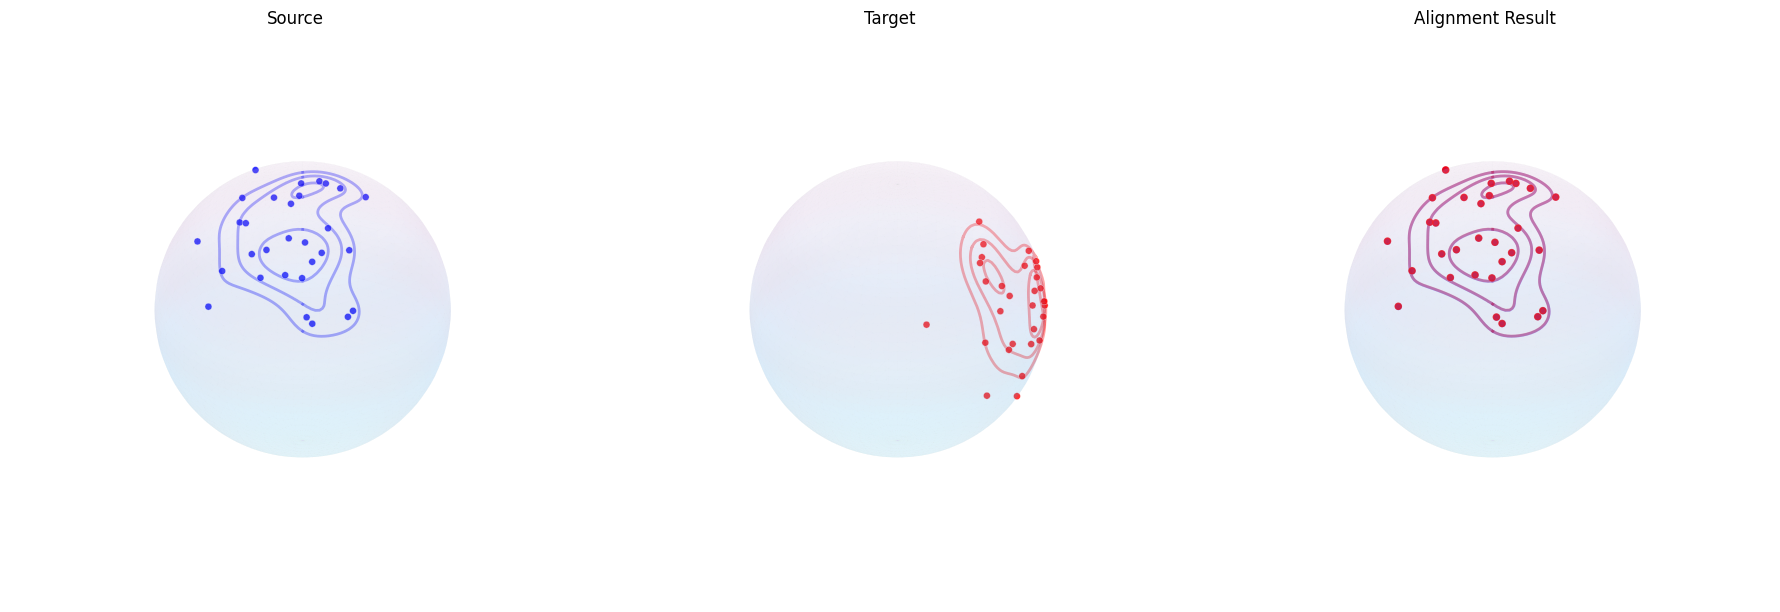

In [15]:
plot_alignment_dashboard(
    data_src, data_tgt, theta_est, 
    src_mesh, tgt_mesh, 
    show_contours=True,
    view_angle=(-30, 0)
)

#### 2. Symmetric vMFs + 1 point pair

Hypothesis: Aligning two VMFs on their respective S2s while also using 1 pair will result in one uniquely determined transformation. 

Reason: Even when the distribution and the objects are isometric, if also using just a single pair of matched points GW can determine the rotation exactly in $\mathbb{R}$.

In [ ]:
# --- single run of symmetric vMF with known anchor pair ---
np.random.seed(42)
epsilon = 0.002
n_res = 50
threshold = 1e-8

layer_radii = [0.1, 0.2, 0.3]
points_per_layer = 4

# Mean direction
mu_src = np.array([1., 0., 0.])

# Construct symmetric source data
data_src = symmetric_samples_vmf(mu_src, layer_radii, points_per_layer)
n_samples = data_src.shape[0]

# Hidden Ground Truth Transformation
theta_true = np.array([np.pi/2, np.pi/3, np.pi/5])
R_true = get_rotation_matrix(theta_true)

# Apply rotation to get target data
data_tgt = (R_true @ data_src.T).T

# Choose a point from the dataset to act as known correspondence
i_anchor = 3
x_pair_src = data_src[i_anchor]
x_pair_tgt = data_tgt[i_anchor]

# Move anchor point to index 0 (so we can enforce it in P)
def move_to_front(data, idx):
    return np.vstack([data[idx:idx+1], np.delete(data, idx, axis=0)])

data_src = move_to_front(data_src, i_anchor)
data_tgt = move_to_front(data_tgt, i_anchor)

# Construct meshes
src_mesh = construct_sphere_mesh(n_res)
tgt_mesh = construct_sphere_mesh(n_res)

# Compute intrinsic geometries
D_src = compute_geodesics(data_src, is_sphere=True)
D_tgt = compute_geodesics(data_tgt, is_sphere=True)

# Uniform mass distributions
a = np.ones(n_samples) / n_samples
b = np.ones(n_samples) / n_samples

# Initialize GW coupling
P_learned = a[:, None] @ b[None, :]

# Enforce anchor correspondence
P_learned[0, :] = 0
P_learned[:, 0] = 0
P_learned[0, 0] = 1

# GW-Sinkhorn iterations
gw_dist_old = float('inf')
converged = False

while not converged:
    cost_gradient = - np.dot(np.dot(D_src, P_learned), D_tgt)

    P_learned = solve_sinkhorn_coupling(cost_gradient, epsilon, a, b)

    # Re-enforce anchor after Sinkhorn step
    P_learned[0, :] = 0
    P_learned[:, 0] = 0
    P_learned[0, 0] = 1

    gw_dist_new = gromov_wasserstein_loss(D_src, D_tgt, P_learned)

    if abs(gw_dist_new - gw_dist_old) < threshold:
        converged = True

    gw_dist_old = gw_dist_new

# Optimize rotation
theta_est = optimize_rotation(np.zeros(3), data_src, data_tgt, P_learned)

# Results
final_gw = gromov_wasserstein_loss(D_src, D_tgt, P_learned)

print("Anchor index (original):", i_anchor)
print("Learned Theta (est):", np.round(theta_est, 4))
print("Ground Truth Theta:", np.round(theta_true, 4))
print("Final GW Distance:", f"{final_gw:.6f}")

Anchor index (original): 3
Learned Theta (est): [-1.5708 -1.0473 -0.6285]
Ground Truth Theta: [1.5708 1.0472 0.6283]
Final GW Distance: 0.016008


Different parametrizations of theta leads to the same map regardless. Both leads to the same map taking different routes to arrive at the same alignment.

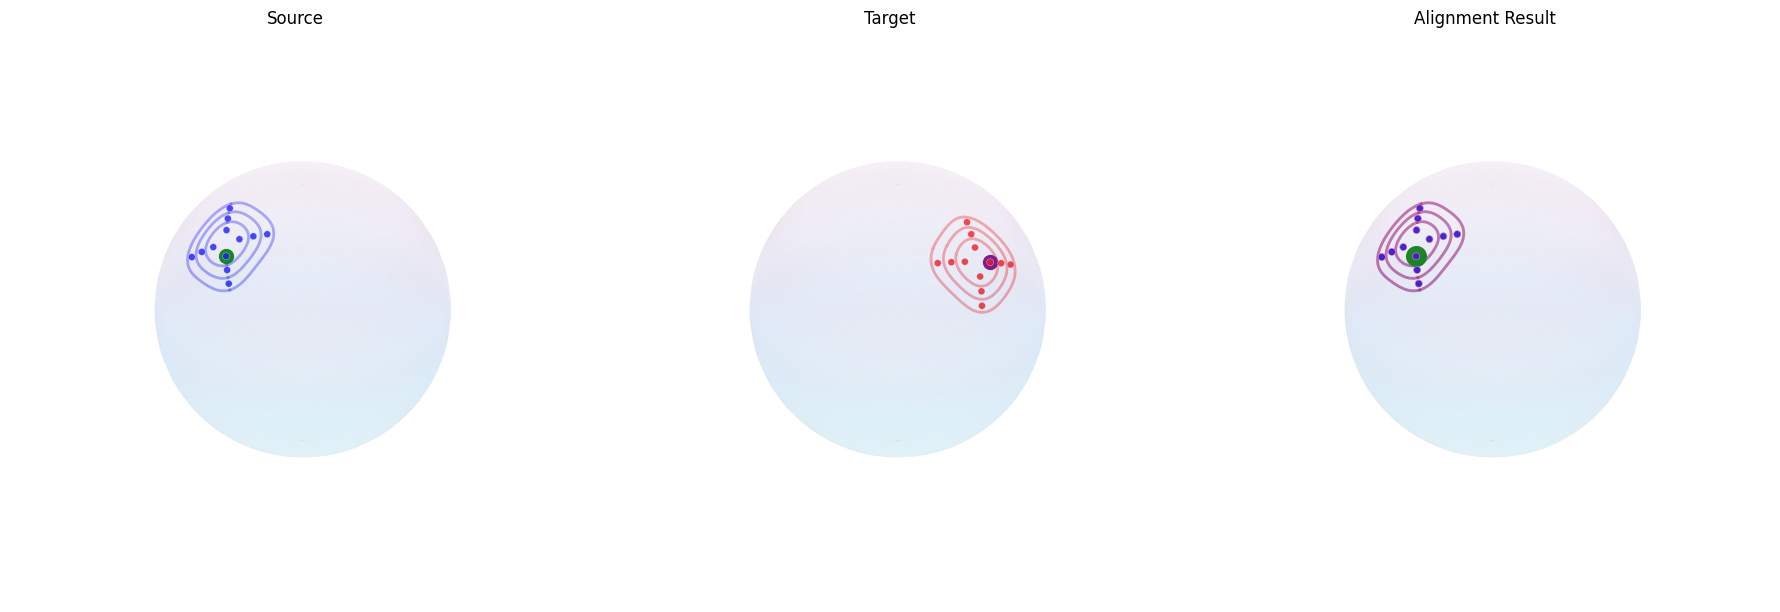

In [20]:
plot_alignment_dashboard(
    data_src, data_tgt, theta_est, 
    src_mesh, tgt_mesh, 
    x_pair_src, x_pair_tgt,
    show_contours=True,
    view_angle=(-30, 30)
)

Over multiple runs with differently initialized thetas all runs should result in one perfect alignment. ->

In [18]:
# --- multiple random theta initializations with known anchor pair ---
np.random.seed(42)
epsilon = 0.002
n_res = 50
threshold = 1e-8
n_theta_inits = 15

layer_radii = [0.1, 0.2, 0.3]
points_per_layer = 4

# Mean direction
mu = np.array([1., 0., 0.])

# Construct symmetric source data
data_src = symmetric_samples_vmf(mu, layer_radii, points_per_layer)
n_samples = data_src.shape[0]

# Hidden Ground Truth Transformation
theta_true = np.array([np.pi/2, np.pi/3, np.pi/5])
R_true = get_rotation_matrix(theta_true)

# Apply rotation to get target data
data_tgt = (R_true @ data_src.T).T

# Choose a single anchor point (fixed across all runs)
i_anchor = 3
x_pair_src = data_src[i_anchor]
x_pair_tgt = data_tgt[i_anchor]

# Move anchor to index 0 (for enforcing P[0,0]=1)
def move_to_front(data, idx):
    return np.vstack([data[idx:idx+1], np.delete(data, idx, axis=0)])

data_src = move_to_front(data_src, i_anchor)
data_tgt = move_to_front(data_tgt, i_anchor)

# Sphere meshes
src_mesh = construct_sphere_mesh(n_res)
tgt_mesh = construct_sphere_mesh(n_res)

# Compute intrinsic geometries
D_src = compute_geodesics(data_src, is_sphere=True)
D_tgt = compute_geodesics(data_tgt, is_sphere=True)

# Uniform mass distributions
a = np.ones(n_samples) / n_samples
b = np.ones(n_samples) / n_samples

# GW-Sinkhorn initialization
P_learned = a[:, None] @ b[None, :]

# Enforce anchor correspondence
P_learned[0, :] = 0
P_learned[:, 0] = 0
P_learned[0, 0] = 1

gw_dist_old = float('inf')
converged = False

while not converged:
    cost_gradient = - np.dot(np.dot(D_src, P_learned), D_tgt)

    P_learned = solve_sinkhorn_coupling(cost_gradient, epsilon, a, b)

    # Re-enforce anchor
    P_learned[0, :] = 0
    P_learned[:, 0] = 0
    P_learned[0, 0] = 1

    gw_dist_new = gromov_wasserstein_loss(D_src, D_tgt, P_learned)

    if abs(gw_dist_new - gw_dist_old) < threshold:
        converged = True

    gw_dist_old = gw_dist_new

# Optimize rotation from multiple random initializations
theta_estimates = []
gw_estimates = []
for _ in range(n_theta_inits):
    init_theta = np.random.randn(3)
    theta_est = optimize_rotation(init_theta, data_src, data_tgt, P_learned)
    theta_estimates.append(theta_est)
    final_gw = gromov_wasserstein_loss(D_src, D_tgt, P_learned)
    gw_estimates.append(final_gw)

print("--- Symmetric Paired Experiment (Multiple Theta Inits) ---")
for i, theta_est in enumerate(theta_estimates):
    print(f"Init {i}: Learned Theta (est): {np.round(theta_est,4)}")

print("Anchor index (original):", i_anchor)
print("Ground Truth Theta:", np.round(theta_true, 4))
print("Final mean GW Distance:", f"{np.mean(gw_estimates):.6f}")
print("--------------------------------------------------------")

--- Symmetric Paired Experiment (Multiple Theta Inits) ---
Init 0: Learned Theta (est): [-1.5707 -1.0473 -0.6285]
Init 1: Learned Theta (est): [3.3893 2.2599 1.356 ]
Init 2: Learned Theta (est): [3.3893 2.2599 1.3559]
Init 3: Learned Theta (est): [-1.5708 -1.0473 -0.6285]
Init 4: Learned Theta (est): [-1.5708 -1.0473 -0.6284]
Init 5: Learned Theta (est): [-1.5708 -1.0473 -0.6285]
Init 6: Learned Theta (est): [-1.5708 -1.0473 -0.6284]
Init 7: Learned Theta (est): [-1.5708 -1.0473 -0.6285]
Init 8: Learned Theta (est): [-1.5708 -1.0473 -0.6285]
Init 9: Learned Theta (est): [-1.5707 -1.0473 -0.6285]
Init 10: Learned Theta (est): [-1.5708 -1.0473 -0.6284]
Init 11: Learned Theta (est): [-1.5707 -1.0473 -0.6285]
Init 12: Learned Theta (est): [-1.5708 -1.0473 -0.6285]
Init 13: Learned Theta (est): [-1.5708 -1.0473 -0.6285]
Init 14: Learned Theta (est): [-1.5708 -1.0473 -0.6284]
Anchor index (original): 3
Ground Truth Theta: [1.5708 1.0472 0.6283]
Final mean GW Distance: 0.016008
--------------

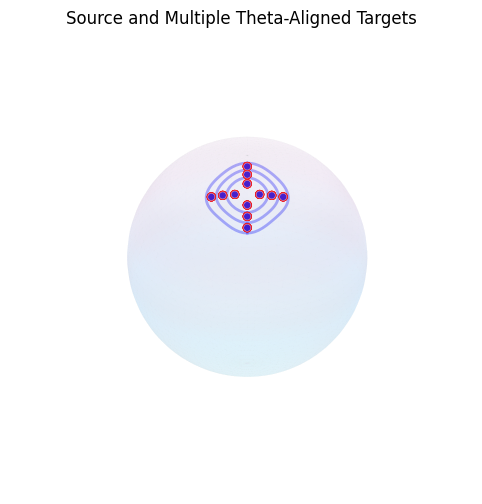

In [22]:
plot_multiple_theta_alignments_correct(
    data_src, data_tgt, theta_estimates,
    src_mesh, tgt_mesh,
    show_contours=True,
    view_angle=(-30,0)
)

Now there is no rotation invariance. The alignment is uniquely determined.

#### 3. Symmetric vMF mixtures (no pairs)

Hypothesis: Aligning two distributions each consisting of a combination of 3 vMFs (all on the sphere ||z||=1) can uniquely determine the rotation. 

Reason: Even when the spheres are isometric, the combination of 3 vMFs will make one very unique distribution (unless they of course are symmetrically placed). Aligning asymmetric distributions are possible using GW-method and will result in a uniquely found rotation.

In [20]:
def symmetric_vmf_mixture(mus, layer_radii, points_per_layer, weights, n_total):
    """
    Construct a mixture of symmetric components on S^2.

    Each component contributes a symmetric ring structure.
    """
    counts = (weights * n_total).astype(int)

    # fix rounding
    counts[-1] += n_total - counts.sum()

    data = []
    for mu, count in zip(mus, counts):
        comp = symmetric_samples_vmf(mu, layer_radii, points_per_layer)

        # repeat / subsample to match desired count
        idx = np.random.choice(len(comp), size=count, replace=True)
        data.append(comp[idx])

    return np.vstack(data)

In [21]:
# --- multiple runs of aligning mixture of vMFs ---
np.random.seed(42)
n_samples = 400
epsilon = 0.02
n_res = 30
threshold = 1e-6
n_theta_inits = 15

n_components = 3 # number of single vMFs in mixture

layer_radii = [0.05, 0.1, 0.15]
points_per_layer = 6

theta_true = np.array([0.3, 1.0, 0.7])
R_true = get_rotation_matrix(theta_true)

src_mesh = construct_sphere_mesh(n_res)
tgt_mesh = construct_sphere_mesh(n_res)

def normalize(v):
    return v / np.linalg.norm(v)

# Random component means
mus_src = []
for _ in range(n_components):
    v = np.random.randn(3)
    mus_src.append(normalize(v))

# Mixture weights
weights = np.random.rand(n_components)
weights /= weights.sum()

# Construct symmetric mixture (source)
data_src = symmetric_vmf_mixture(
    mus_src,
    layer_radii,
    points_per_layer,
    weights,
    n_samples
)

# Rotate to get target (exact correspondence preserved)
data_tgt = (R_true @ data_src.T).T

# Compute intrinsic geometries
D_src = compute_geodesics(data_src, is_sphere=True)
D_tgt = compute_geodesics(data_tgt, is_sphere=True)

# Uniform measures
a = np.ones(n_samples) / n_samples
b = np.ones(n_samples) / n_samples

# GW-Sinkhorn
P_learned = a[:, None] @ b[None, :]
gw_dist_old = float('inf')
converged = False

while not converged:
    cost_gradient = - np.dot(np.dot(D_src, P_learned), D_tgt)
    P_learned = solve_sinkhorn_coupling(cost_gradient, epsilon, a, b)

    gw_dist_new = gromov_wasserstein_loss(D_src, D_tgt, P_learned)

    if abs(gw_dist_new - gw_dist_old) < threshold:
        converged = True

    gw_dist_old = gw_dist_new

# Multiple theta optimizations
theta_estimates = []
gw_estimates = []
for _ in range(n_theta_inits):
    init_theta = np.random.randn(3)
    theta_est = optimize_rotation(init_theta, data_src, data_tgt, P_learned)
    theta_estimates.append(theta_est)
    gw_estimates.append(gromov_wasserstein_loss(D_src,D_tgt,P_learned))


print("--- Symmetric Mixture Experiment (Multiple Theta Inits) ---")
for i, theta_est in enumerate(theta_estimates):
    print(f"Init {i}: Learned Theta (est): {np.round(theta_est,4)}")

print("Ground Truth Theta:", np.round(theta_true, 4))
print("Final GW Distnance:", f"{np.mean(final_gw):.6f}")
print("----------------------------------------------------------")

--- Symmetric Mixture Experiment (Multiple Theta Inits) ---
Init 0: Learned Theta (est): [-0.301  -1.0019 -0.7001]
Init 1: Learned Theta (est): [-0.301  -1.0019 -0.7001]
Init 2: Learned Theta (est): [-0.301  -1.0019 -0.7001]
Init 3: Learned Theta (est): [-15.3271 -51.0136 -35.6413]
Init 4: Learned Theta (est): [1.2015 3.9991 2.7944]
Init 5: Learned Theta (est): [-0.301  -1.0019 -0.7001]
Init 6: Learned Theta (est): [-0.301  -1.0019 -0.7001]
Init 7: Learned Theta (est): [-0.301  -1.0019 -0.7001]
Init 8: Learned Theta (est): [-0.301  -1.0019 -0.7001]
Init 9: Learned Theta (est): [-0.301  -1.0019 -0.7001]
Init 10: Learned Theta (est): [-0.301  -1.0019 -0.7001]
Init 11: Learned Theta (est): [-0.301  -1.0019 -0.7001]
Init 12: Learned Theta (est): [1.2015 3.999  2.7945]
Init 13: Learned Theta (est): [-0.301  -1.0019 -0.7001]
Init 14: Learned Theta (est): [-0.301  -1.0019 -0.7001]
Ground Truth Theta: [0.3 1.  0.7]
Final GW Distnance: 0.016008
--------------------------------------------------

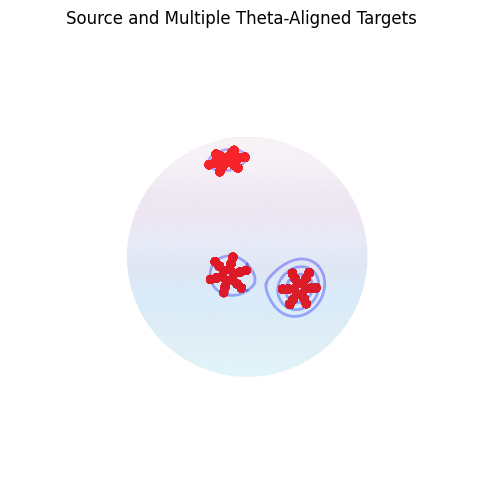

In [28]:
plot_multiple_theta_alignments_correct(
    data_src, data_tgt, theta_estimates,
    src_mesh, tgt_mesh,
    show_contours=True,
    view_angle=(0,0)
)

Concluding:

* The alignment is uniquely determined when using a mixture of (symmetric) vMFs, as this becomes an asymmetric distribution. 
* The GW-method can be used to determine alignment when the distributions can be modelled as a multi-component structure.

**Showing an xample of vMF mixture, when the vMFs are not symmetrically sampled**:

Showing that it is possible to obtain alignment even when the data is not symmetrical. Alignment in this case, needs to be evaluated on how exact and *perfect* it is, taking into regard that the alignment cannot be perfect when the samples are not the same in the source and target domains. The GW distance can still however be minimized and if the data is sampled from the same underlying distribution the alignment will overlay the two distributions.

In [ ]:
# --- mixture of independently sampled vMFs ----
np.random.seed(42)
n_samples = 400
epsilon = 0.02
n_res = 30
threshold = 1e-6

n_components = 3

theta_true = np.array([0.3, 1.0, 0.7])
R_true = get_rotation_matrix(theta_true)

src_mesh = construct_sphere_mesh(n_res)
tgt_mesh = construct_sphere_mesh(n_res)

def normalize(v):
    return v / np.linalg.norm(v)


mus_src = []
for _ in range(n_components):
    v = np.random.randn(3)
    mus_src.append(normalize(v))

kappas = np.random.uniform(10, 40, size=n_components)

weights = np.random.rand(n_components)
weights /= weights.sum()

mus_tgt = [R_true @ mu for mu in mus_src]

def sample_vmf_mixture(mus, kappas, weights, n_samples):
    components = np.random.choice(len(mus), size=n_samples, p=weights)
    samples = np.zeros((n_samples, 3))
    for i, c in enumerate(components):
        x = sample_vmf_on_sphere(mus[c], kappa=kappas[c], n_samples=1)[0]
        samples[i] = x
    samples /= np.linalg.norm(samples, axis=1, keepdims=True)
    return samples

data_src = sample_vmf_mixture(mus_src, kappas, weights, n_samples)
data_tgt = sample_vmf_mixture(mus_tgt, kappas, weights, n_samples)

D_src = compute_geodesics(data_src, is_sphere=True)
D_tgt = compute_geodesics(data_tgt, is_sphere=True)

a = np.ones(n_samples) / n_samples
b = np.ones(n_samples) / n_samples

P_learned = a[:, None] @ b[None, :]
gw_dist_old = float('inf')
converged = False

while not converged:
    cost_gradient = - np.dot(np.dot(D_src, P_learned), D_tgt)
    P_learned = solve_sinkhorn_coupling(cost_gradient, epsilon, a, b)
    gw_dist_new = gromov_wasserstein_loss(D_src, D_tgt, P_learned)
    if abs(gw_dist_new - gw_dist_old) < threshold:
        converged = True
    gw_dist_old = gw_dist_new

theta_est = optimize_rotation(np.zeros(3), data_src, data_tgt, P_learned)

final_gw = gromov_wasserstein_loss(D_src, D_tgt, P_learned)

print("--- Experiment 3 Results ---")
print(f"Learned Theta (est): {np.round(theta_est, 4)}")
print(f"Ground Truth Theta:  {np.round(theta_true, 4)}")
print(f"Final GW Distance: {final_gw:.6f}")
print("--------------------------")


--- Experiment 3 Results ---
Learned Theta (est): [-0.2969 -1.053  -0.6934]
Ground Truth Theta:  [0.3 1.  0.7]
Final GW Discrepancy: 0.081953
--------------------------


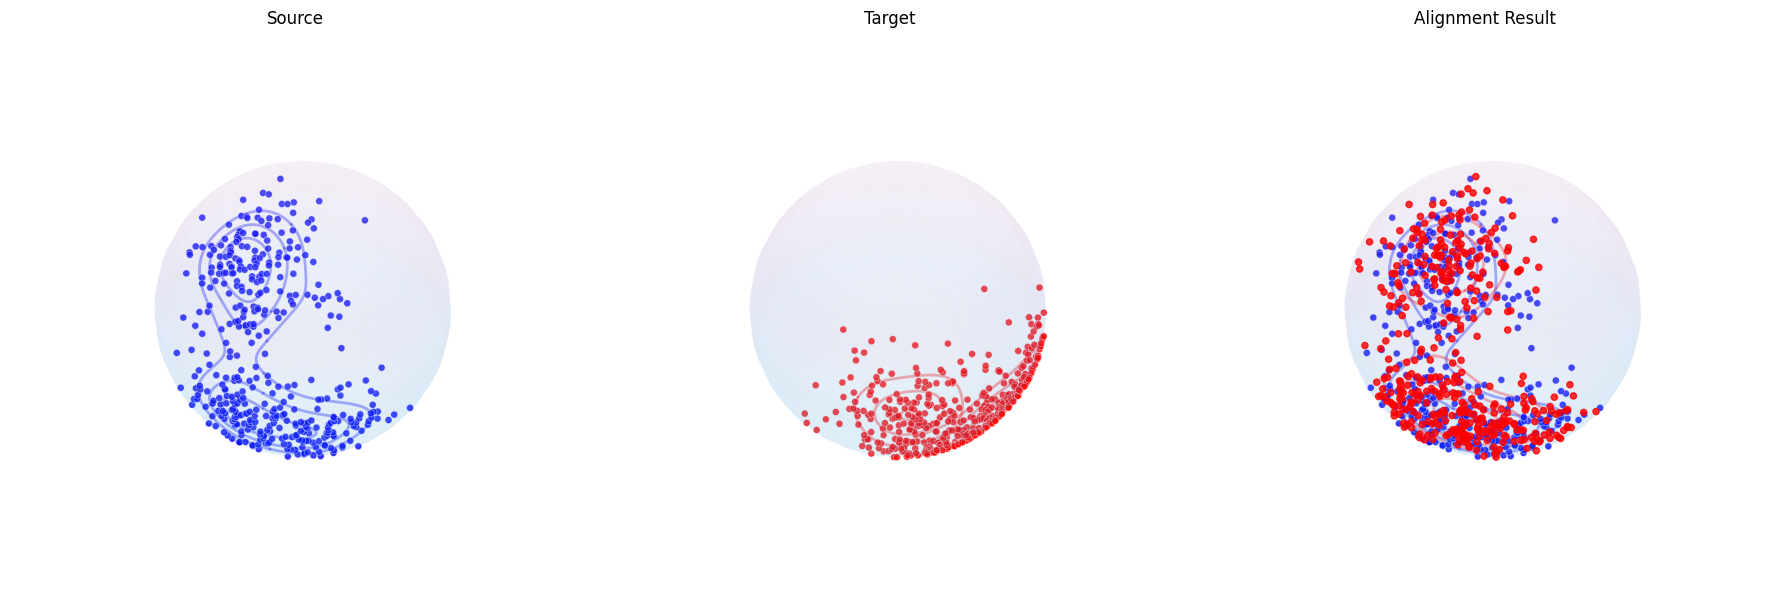

In [24]:

plot_alignment_dashboard(
    data_src,
    data_tgt,
    theta_est,
    src_mesh,
    tgt_mesh,
    show_contours=True,
    view_angle=(40, 15)
)

Concluding:

* When the data is not symmetric, the alignment is not perfect nor unique, but the GW-method still finds the structure of the underlying distributions. 
* Visually the alignment is not bad. Measured on the GW-distance the alignment is also not bad.
* The alignment would become more perfect if we sampled (infinitely many) more points. It is when the data is symmetric - a forced true construction of a (mixture of) vMF we can showcase this perfect alignment is possible using GW on a mixture of symmetric distributions.

#### 4. Symmetric vMFs with noise (no pairs)

Hypothesis: Aligning two vMFs with noise on their respective S2s is the problem of aligning two deformed spheres (i.e. potato shapes). It will be possible to obtain a unique alignment if locally around any point as the mean of the distribution the object is asymmetrical.

Reason: An asymmetric distribution will result in unique distances between points, so will deforming the object on which the distribution is layed upon. GW obtains unique alignments if the distances between the points are unique.

In [ ]:
# ex4 helper functions
def symmetric_rings_vmf(mu, layer_radii, points_per_layer, phase_offsets=None):
    """
    Symmetric rings around mu on S^2.
    Each ring is individually symmetric, but using different numbers of points
    per ring removes a common rotational symmetry of the full sampled set.
    """
    mu = np.asarray(mu, dtype=float)
    mu = mu / np.linalg.norm(mu)

    if np.allclose(mu, np.array([1.0, 0.0, 0.0])):
        v1 = np.array([0.0, 1.0, 0.0])
    else:
        v1 = np.cross(mu, np.array([1.0, 0.0, 0.0]))
        if np.linalg.norm(v1) < 1e-8:
            v1 = np.cross(mu, np.array([0.0, 1.0, 0.0]))

    v1 = v1 / np.linalg.norm(v1)
    v2 = np.cross(mu, v1)

    if phase_offsets is None:
        phase_offsets = np.zeros(len(layer_radii))

    pts = []
    for r, m, phi0 in zip(layer_radii, points_per_layer, phase_offsets):
        angles = phi0 + np.linspace(0.0, 2.0 * np.pi, m, endpoint=False)
        ring = (
            mu[None, :]
            + r * np.cos(angles)[:, None] * v1[None, :]
            + r * np.sin(angles)[:, None] * v2[None, :]
        )
        ring /= np.linalg.norm(ring, axis=1, keepdims=True)
        pts.append(ring)

    return np.vstack(pts)



def create_deformation_params(seed):
    """
    simple asymmetric deformation
        alpha = 0  -> sphere
        alpha = 1  -> strongly deformed sphere
    """
    rng = np.random.RandomState(seed)
    dirs = []
    for _ in range(3):
        d = rng.randn(3)
        d /= np.linalg.norm(d)
        dirs.append(d)
    return tuple(dirs)


def deform_sphere(points_on_sphere, alpha, params):
    d1, d2, d3 = params

    s1 = points_on_sphere @ d1
    s2 = points_on_sphere @ d2
    s3 = points_on_sphere @ d3

    # purely radial, clearly asymmetric
    radial_scale = (
        1.0
        + alpha * (
            0.28 * s1
            + 0.18 * s2**2
            - 0.22 * s3**3
            + 0.12 * np.sin(4.0 * s1 + 0.3)
        )
    )

    return radial_scale[:, None] * points_on_sphere


In [ ]:
# --- multiple vMFs with noise ----
np.random.seed(42)
epsilon = 0.02
threshold = 1e-7
max_gw_iter = 300
n_theta_inits = 10
n_res = 40

alpha = 1
deformation_seed = 7

mu = np.array([1.0, 0.0, 0.0])

# Different cardinalities break the global rotation-around-mean ambiguity.
layer_radii = [0.05, 0.10, 0.15, 0.20]
points_per_layer = [7, 9, 11, 13]
phase_offsets = [0.00, 0.15, -0.10, 0.22]

# Source data in parameter space, then deform once
data_param = symmetric_rings_vmf(
    mu=mu,
    layer_radii=layer_radii,
    points_per_layer=points_per_layer,
    phase_offsets=phase_offsets
)

params = create_deformation_params(deformation_seed)
data_src = deform_sphere(data_param, alpha, params)

# hidden rotation
theta_true = np.array([0.35, 0.90, -0.55])
R_true = get_rotation_matrix(theta_true)
data_tgt = (R_true @ data_src.T).T

# meshes for plotting
base_vertices, base_faces = construct_sphere_mesh(n_res)
src_vertices = deform_sphere(base_vertices, alpha, params)
tgt_vertices = (R_true @ src_vertices.T).T

src_mesh = (src_vertices, base_faces)
tgt_mesh = (tgt_vertices, base_faces)

# ----------------------------
# GW coupling
# ----------------------------
D_src = compute_geodesics(data_src, is_sphere=False)
D_tgt = compute_geodesics(data_tgt, is_sphere=False)

n = data_src.shape[0]
a = np.ones(n) / n
b = np.ones(n) / n

P = a[:, None] @ b[None, :]
gw_old = np.inf

for _ in range(max_gw_iter):
    cost_gradient = -D_src @ P @ D_tgt
    P = solve_sinkhorn_coupling(cost_gradient, epsilon, a, b)
    gw_new = gromov_wasserstein_loss(D_src, D_tgt, P)

    if abs(gw_new - gw_old) < threshold:
        break
    gw_old = gw_new

final_gw = gromov_wasserstein_loss(D_src, D_tgt, P)

# ----------------------------
# Deterministic rotation recovery from coupling
# we do NOT optimize theta here.
# Recover R directly from the GW coupling.
# ----------------------------
R_hat, t_hat = fit_orthogonal_map_from_coupling(data_src, data_tgt, P)

# principal rotation-vector parametrization
theta_hat = Rot.from_matrix(R_hat).as_rotvec()
theta_true_principal = Rot.from_matrix(R_true).as_rotvec()

aligned = data_tgt @ R_hat + t_hat

# ----------------------------
# Repeating with different theta initializations, to show that the result does not depend on theta init.
# ----------------------------
theta_inits = []
theta_hats = []
R_diffs = []
align_errors = []

for _ in range(n_theta_inits):
    theta_init = np.random.randn(3)
    theta_inits.append(theta_init)

    theta_hats.append(theta_hat.copy())
    R_diffs.append(np.linalg.norm(R_hat - R_hat, ord="fro"))   # always 0 by design
    align_errors.append(np.mean(np.linalg.norm(data_src - aligned, axis=1)))

theta_inits = np.array(theta_inits)
theta_hats = np.array(theta_hats)
R_diffs = np.array(R_diffs)
align_errors = np.array(align_errors)

print("----- Experiment 4: symmetric rings on asymmetric object -----")
print(f"alpha                : {alpha}")
print(f"n_points             : {n}")
print(f"final GW distance    : {final_gw:.8f}")
print(f"theta_true (principal): {np.round(theta_true_principal, 6)}")
print(f"theta_hat  (principal): {np.round(theta_hat, 6)}")
print(f"mean alignment error : {align_errors.mean():.8e}")
print(f"std  alignment error : {align_errors.std():.8e}")
print(f"max ||R_i - R_1||_F  : {R_diffs.max():.8e}")
print()

print("Repeated runs with different theta initializations:")
for i in range(n_theta_inits):
    print(
        f"run {i:02d} | "
        f"theta_init = {np.round(theta_inits[i], 4)} | "
        f"theta_hat = {np.round(theta_hats[i], 6)} | "
        f"mean_err = {align_errors[i]:.8e}"
    )

----- Experiment 4: symmetric rings on asymmetric object -----
alpha                : 1
n_points             : 40
final GW distance    : 0.02287924
theta_true (principal): [ 0.35  0.9  -0.55]
theta_hat  (principal): [ 0.35  0.9  -0.55]
mean alignment error : 3.24936466e-13
std  alignment error : 5.04870979e-29
max ||R_i - R_1||_F  : 0.00000000e+00

Repeated runs with different theta initializations:
run 00 | theta_init = [ 0.4967 -0.1383  0.6477] | theta_hat = [ 0.35  0.9  -0.55] | mean_err = 3.24936466e-13
run 01 | theta_init = [ 1.523  -0.2342 -0.2341] | theta_hat = [ 0.35  0.9  -0.55] | mean_err = 3.24936466e-13
run 02 | theta_init = [ 1.5792  0.7674 -0.4695] | theta_hat = [ 0.35  0.9  -0.55] | mean_err = 3.24936466e-13
run 03 | theta_init = [ 0.5426 -0.4634 -0.4657] | theta_hat = [ 0.35  0.9  -0.55] | mean_err = 3.24936466e-13
run 04 | theta_init = [ 0.242  -1.9133 -1.7249] | theta_hat = [ 0.35  0.9  -0.55] | mean_err = 3.24936466e-13
run 05 | theta_init = [-0.5623 -1.0128  0.3142]

In [36]:
def plot_experiment4_alignment(
    data_src,
    data_tgt,
    R_hat,
    t_hat,
    src_mesh,
    tgt_mesh,
    view_angle=(-30, 0),
    show_contours=False,
    is_sphere=False,
):
    """
    3-panel plot in the same style as plot_alignment_dashboard,
    but using the estimated affine map (R_hat, t_hat) directly.
    """

    # affine alignment of target points
    aligned_tgt = apply_affine_map(data_tgt, R_hat, t_hat)

    # affine alignment of target mesh
    tgt_vertices, tgt_faces = tgt_mesh
    aligned_tgt_vertices = apply_affine_map(tgt_vertices, R_hat, t_hat)
    aligned_tgt_mesh = (aligned_tgt_vertices, tgt_faces)

    fig = plt.figure(figsize=(18, 6))

    # Source
    ax1 = fig.add_subplot(131, projection='3d')
    plot_object_points(src_mesh, data_src, 'blue', ax1, show_contours, is_sphere)
    ax1.set_title("Source")
    ax1.view_init(*view_angle)

    # Target
    ax2 = fig.add_subplot(132, projection='3d')
    plot_object_points(tgt_mesh, data_tgt, 'red', ax2, show_contours, is_sphere)
    ax2.set_title("Target")
    ax2.view_init(*view_angle)

    # Alignment
    ax3 = fig.add_subplot(133, projection='3d')
    plot_object_points(aligned_tgt_mesh, aligned_tgt, 'red', ax3, show_contours, is_sphere)

    ax3.scatter(
        data_src[:, 0], data_src[:, 1], data_src[:, 2],
        color='blue', s=25, alpha=0.8,
        edgecolor='white', linewidth=0.3, label='source'
    )

    ax3.scatter(
        aligned_tgt[:, 0], aligned_tgt[:, 1], aligned_tgt[:, 2],
        color='red', s=25, alpha=0.8,
        edgecolor='white', linewidth=0.3, label='aligned target'
    )

    ax3.set_title("Alignment Result")
    ax3.view_init(*view_angle)
    ax3.legend()

    plt.tight_layout()
    plt.show()

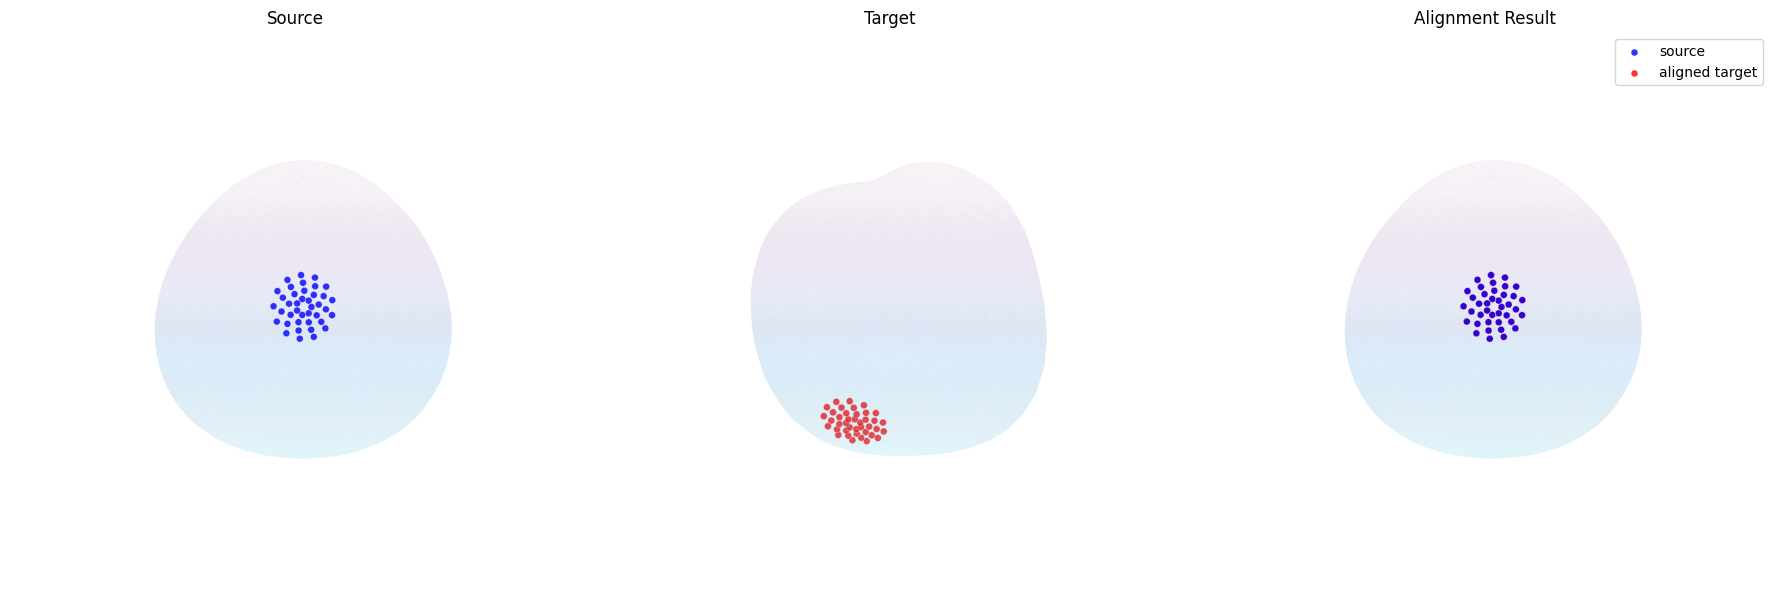

In [47]:
plot_experiment4_alignment(
    data_src,
    data_tgt,
    R_hat,
    t_hat,
    src_mesh,
    tgt_mesh,
    view_angle=(0, 0),   
    show_contours=False,
    is_sphere=False,
)

Concluding:

* Alignment is possible because the deformation breaks symmetric geometry that leads to rotation invariance in the GW solution.
* The same alignment is found when initialized with different thetas.
* The unique alignment is only possible when the deformation of the object sufficiently distorts pairwise distances
* Does the alignment get better when alpha is small (less deformed)?

In [48]:
# small check of how asymmetric the deformation actually is.

def check_axial_symmetry(points_on_sphere, alpha, params, mu, n_bins=20):
    """
    Returns how much the deformation varies along circles around mu.
    If near 0, the deformation is approximately axisymmetric around mu.
    """
    mu = mu / np.linalg.norm(mu)

    deformed = deform_sphere(points_on_sphere, alpha, params)
    radii = np.linalg.norm(deformed, axis=1)

    proj = points_on_sphere @ mu   # same proj = same polar level wrt mu

    edges = np.linspace(-1.0, 1.0, n_bins + 1)
    bin_std = []

    for i in range(n_bins):
        mask = (proj >= edges[i]) & (proj < edges[i + 1])
        if np.sum(mask) >= 5:
            bin_std.append(np.std(radii[mask]))

    return np.mean(bin_std), np.max(bin_std)

In [49]:
sphere_vertices, _ = construct_sphere_mesh(80)
mean_std, max_std = check_axial_symmetry(sphere_vertices, alpha, params, mu)

print("mean within-ring std:", mean_std)
print("max  within-ring std:", max_std)

mean within-ring std: 0.0638185520869478
max  within-ring std: 0.10209330023154302


Radial ca 1 => ca 0.04 svarer til 4% variation, det er asymmetrisk. (derfor virker GW).